# Electric Motor Temperature Estimation

**Link**

https://www.kaggle.com/wkirgsn/electric-motor-temperature


**Context**

The data set comprises several sensor data collected from a permanent magnet synchronous motor (PMSM) deployed on a test bench. The PMSM represents a german OEM's prototype model. Test bench measurements were collected by the LEA department at Paderborn University. This data set is mildly anonymized.

**Content**

All recordings are sampled at 2 Hz. The data set consists of multiple measurement sessions, which can be distinguished from each other by column `profile_id`. A measurement session can be between one and six hours long.

The motor is excited by hand-designed driving cycles denoting a reference motor speed and a reference torque. Currents in d/q-coordinates (columns `i_d` and `i_q`) and voltages in d/q-coordinates (columns `u_d` and `u_q`) are a result of a standard control strategy trying to follow the reference speed and torque. Columns `motor_speed` and `torque` are the resulting quantities achieved by that strategy, derived from set currents and voltages.

Most driving cycles denote random walks in the speed-torque-plane in order to imitate real world driving cycles to a more accurate degree than constant excitations and ramp-ups and -downs would.

The dataset contains following attributes:
- u_q - Voltage q-component measurement in dq-coordinates (in V)
- coolant - Coolant temperature (in °C)
- stator_winding - Stator winding temperature (in °C) measured with thermocouples
- u_d - Voltage d-component measurement in dq-coordinates
- stator_tooth - Stator tooth temperature (in °C) measured with thermocouples
- motor_speed - Motor speed (in rpm)
- i_d - Current d-component measurement in dq-coordinates
- i_q - Current q-component measurement in dq-coordinates
- pm - Permanent magnet temperature (in °C) measured with thermocouples 
- stator_yoke - Stator yoke temperature (in °C) measured with thermocouples
- ambient - Ambient temperature (in °C)
- torque - Motor torque (in Nm)
- profile_id - Measurement session id. Each distinct measurement session can be identified through this integer id.

The `pm` attribute is our target variable, which should be predicted depending on new measurements.

**Task (Regression)**

Your task is to use the present data set to predict the temperature of the motor's permanent magnet. To do this, you will be assigned a group-specific baseline method (see separate document). You must also independently explore and evaluate additional methods of your own choice. Based on your experiments, select the two most promising methods (which may include your assigned method) and perform hyperparameter tuning on them. Finally, compare these tuned models and decide on a single final model for your prediction.

Throughout the project, you will be competing indirectly with the other groups. However, the final grade is not based solely on the highest prediction accuracy. Instead, we will assess the quality of your entire workflow: your documentation of decisions (including failed attempts and why they failed), your reasoning for choosing specific methods and evaluation metrics, and the justification for your final model selection. The "best" model is not necessarily the one with the lowest error – consider what matters most in a real-world application.

First of all, get an overview of the project in your group. Then carefully read the checklist for machine learning projects and think about how you want to organize your group work. It is strongly recommended that all task items are completed by all group members. You can divide the focus among yourself, but make sure that all members are as well informed as possible about the content.

Use the checklist for machine learning projects as a guide when working on the task. Document all the individual steps that are listed there (all main and secondary items as long as they are applicable to the individual task). Make sure to use Markdown Cells for your documentation. Document the functionality of your algorithms (all three) with equations and explanations. Dont forget, this project is a task for multiple students. We expect a detailed documentation of your approach and your results.

**Note**

We are aware that there are examples and solutions for the selected data sets on popular platforms, e.g. Kaggle. You are welcome to use them as a guide. But remember that at the end of the project, your own work will be assessed. We compare the results with the popular solutions of common platforms. We would like to recognize the independence in your work and see a difference to the existing solution approaches.

**We want to see your own contribution. Therefore, the grade 1.0 is only given to student groups who have dealt with the topic very well and who have developed their own new solution proposals.**

# 1. Frame the Problem and Look at the Big Picture

### 1.1 Define the Object

In this priject we have to train a ML-Model, that predicts the temperature of the permanent magnet inside an electric motor. Therefore we have to use the Method **K-Nearest-Neighbors** (KNN). Anditionaly wie have to shose some more methods and then choos the best one of these. To compare ale the testeted models among each othe we have to choose performence criteria wich we will do in the following paragraph. After that we will have two models (KNN and a second one) wich we neet to fine tune. After fine tuning, we compare both results and then choose the best performing model for our final prediction. 

### 1.2 Select a performance criteria

To rate the performance of the tested model, we will use the **Root Mean Square Error (RMSE)**. This metric is typically used for regression tasks. ite measures the distance between two vevtors. In our case between the prediction and the target value. It also weights larger errors heigher than smal ones. The formula to compute the RMSE is:

$RMSE(X,h) = \sqrt{\frac{1}{m}\sum_{i=1}^{m} (h(x^{(i)})-y^{(i)})^2}$

- $m$ ist the number of instances in our dataset we are measuring. *Our Dataset has more than 1.000.000 columns, eaquals m the complete number of instances of the dataset or can we pic a lower number?* --> m ist die größe unseres Testdatensatzees!
- $x^{(i)}$ ist a vector of alss th features in our dataset. I.e. we have 12 different features and one result (Teparature of the permanent magnet in °C). Thes result ist defined by $y^{(i)}$ in the formula.
- $X$ is a matrix containing all the feature values (excluding labels) of all instances in
the dataset.
- $h$ is your system’s prediction function, also called a hypothesis. When your system is given an instance’s feature vector $x^{(i)}$, it outputs a predicted value $\hat y^{(i)} = h(x^{(i)})$
      * For example: If our system predicts am temperature of $132 °C$, than $\hat y^{(1)} = h(x^{(1)}) = 132 °C$. When the measured temperature is  $y^{(1)} = 138 °C$, than the prediction error for this instance is: $\hat y^{(1)} - y^{(1)} = 6 °C$

Additionally, we will use the Coefficient of Determination ($R^2$) as a supplementary metric. It measures how well the model explains the variance in the target variable and ranges from 0 to 1, where 1 indicates a perfect fit. The formula is:

$$R^2 = 1 - \frac{\sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)})^2}{\sum_{i=1}^{m}(y^{(i)} - \bar{y})^2}$$

- $\bar{y}$ is the mean of all target values
While RMSE gives us the absolute prediction error in °C, R2R^2
R2 allows us to assess the overall explanatory power of the model independently of the unit. Together, both metrics give a more complete picture of model performance.

### 1.3 How to solve the Pproblem manually?

To solve this Problem manually, it is just not possible to look at all insatnces (over 1.000.000), so we would pick some samples. Than we could look for some correlations. For example between the magnetic current and the temperature of the magnet ore between the motor speed and the temperature. With our engineering background we can than try to figger out if there are any correlations. This preocedere would be more of an intuitive method. But with this amound of Instances it is impossible for a human to solve the problem in the same way as a ML-Model can do.

### 1.4 Assumptions

At this point of the project we have not lookt at the data, but we already now somethic through the discription in this notebook.

We assume that:

- the dataset has no false values in it
- there are no gaps in the dataset that are too large to fill it with known functions in python
- it is in general porrible to predict the temperature becouose there is a connection between the temperature and the other attributes
- 

## 2 Get the Data

We import the two standard libraries for data manipulation and numerical 
computation. `pandas` is used to load and manage the dataset as a DataFrame, 
while `numpy` provides efficient numerical operations.

In [2]:
import pandas as pd  # Lädt die wohl bekannteste Bibliothek "Pandas"
import numpy as np   # Lädt die Biblieothek "numpy" für mathematische Berechnungen

Now we can load the date into the project (df steht hier für DateFrame)

In [3]:
df = pd.read_csv("C:/Users/janma/OneDrive - TH Köln/Masterstudium/2. Semester/Machine Learning/Group Project/measures_v2.csv/measures_v2.csv")

we can now controle the data with `df.head()` which gives us the frist 5 colums of the dataframe

### 2.1 Check the Data

In [4]:
df.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


We can see that there are 13 attributes, as we expected

To get an overview of the type and the siize of the dataset, we can use `df.info()`which givs us exactly this overview

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1330816 entries, 0 to 1330815
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   u_q             1330816 non-null  float64
 1   coolant         1330816 non-null  float64
 2   stator_winding  1330816 non-null  float64
 3   u_d             1330816 non-null  float64
 4   stator_tooth    1330816 non-null  float64
 5   motor_speed     1330816 non-null  float64
 6   i_d             1330816 non-null  float64
 7   i_q             1330816 non-null  float64
 8   pm              1330816 non-null  float64
 9   stator_yoke     1330816 non-null  float64
 10  ambient         1330816 non-null  float64
 11  torque          1330816 non-null  float64
 12  profile_id      1330816 non-null  int64  
dtypes: float64(12), int64(1)
memory usage: 132.0 MB


We knew that there were more than 1.000.000 instances but now we know exactly, that there are 1.330.816 entries in the list. 

Every attribute is from type float64 except *profile_id*. But there are no attributes from Dtype `string`. So we don't need to convert any attributes bevause our ML-Model can work with the data as we found it.

We can also see, that there ale no gaps in the dataset. That is very good, because we don't need to fihure out a method to fill any caps.

For a greater overview we can also use some more functions

In [7]:
df.describe()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
count,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06
mean,5.427900e+01,3.622999e+01,6.634275e+01,-2.513381e+01,5.687858e+01,2.202081e+03,-6.871681e+01,3.741278e+01,5.850678e+01,4.818796e+01,2.456526e+01,3.110603e+01,4.079306e+01
std,4.417323e+01,2.178615e+01,2.867206e+01,6.309197e+01,2.295223e+01,1.859663e+03,6.493323e+01,9.218188e+01,1.900150e+01,1.999100e+01,1.929522e+00,7.713575e+01,2.504549e+01
min,-2.529093e+01,1.062375e+01,1.858582e+01,-1.315304e+02,1.813398e+01,-2.755491e+02,-2.780036e+02,-2.934268e+02,2.085696e+01,1.807669e+01,8.783478e+00,-2.464667e+02,2.000000e+00
25%,1.206992e+01,1.869814e+01,4.278796e+01,-7.869090e+01,3.841601e+01,3.171107e+02,-1.154061e+02,1.095863e+00,4.315158e+01,3.199033e+01,2.318480e+01,-1.374265e-01,1.700000e+01
50%,4.893818e+01,2.690014e+01,6.511013e+01,-7.429755e+00,5.603635e+01,1.999977e+03,-5.109376e+01,1.577401e+01,6.026629e+01,4.562551e+01,2.479733e+01,1.086035e+01,4.300000e+01
75%,9.003439e+01,4.985749e+01,8.814114e+01,1.470271e+00,7.558668e+01,3.760639e+03,-2.979688e+00,1.006121e+02,7.200837e+01,6.146083e+01,2.621702e+01,9.159718e+01,6.500000e+01
max,1.330370e+02,1.015985e+02,1.413629e+02,1.314698e+02,1.119464e+02,6.000015e+03,5.189670e-02,3.017079e+02,1.136066e+02,1.011480e+02,3.071420e+01,2.610057e+02,8.100000e+01


df.describe() gives us a summary about the data

- mean = mean value
- std = Standard deviation
- min/max = smales and biggest value
- 25%,50%,75% = Quartile

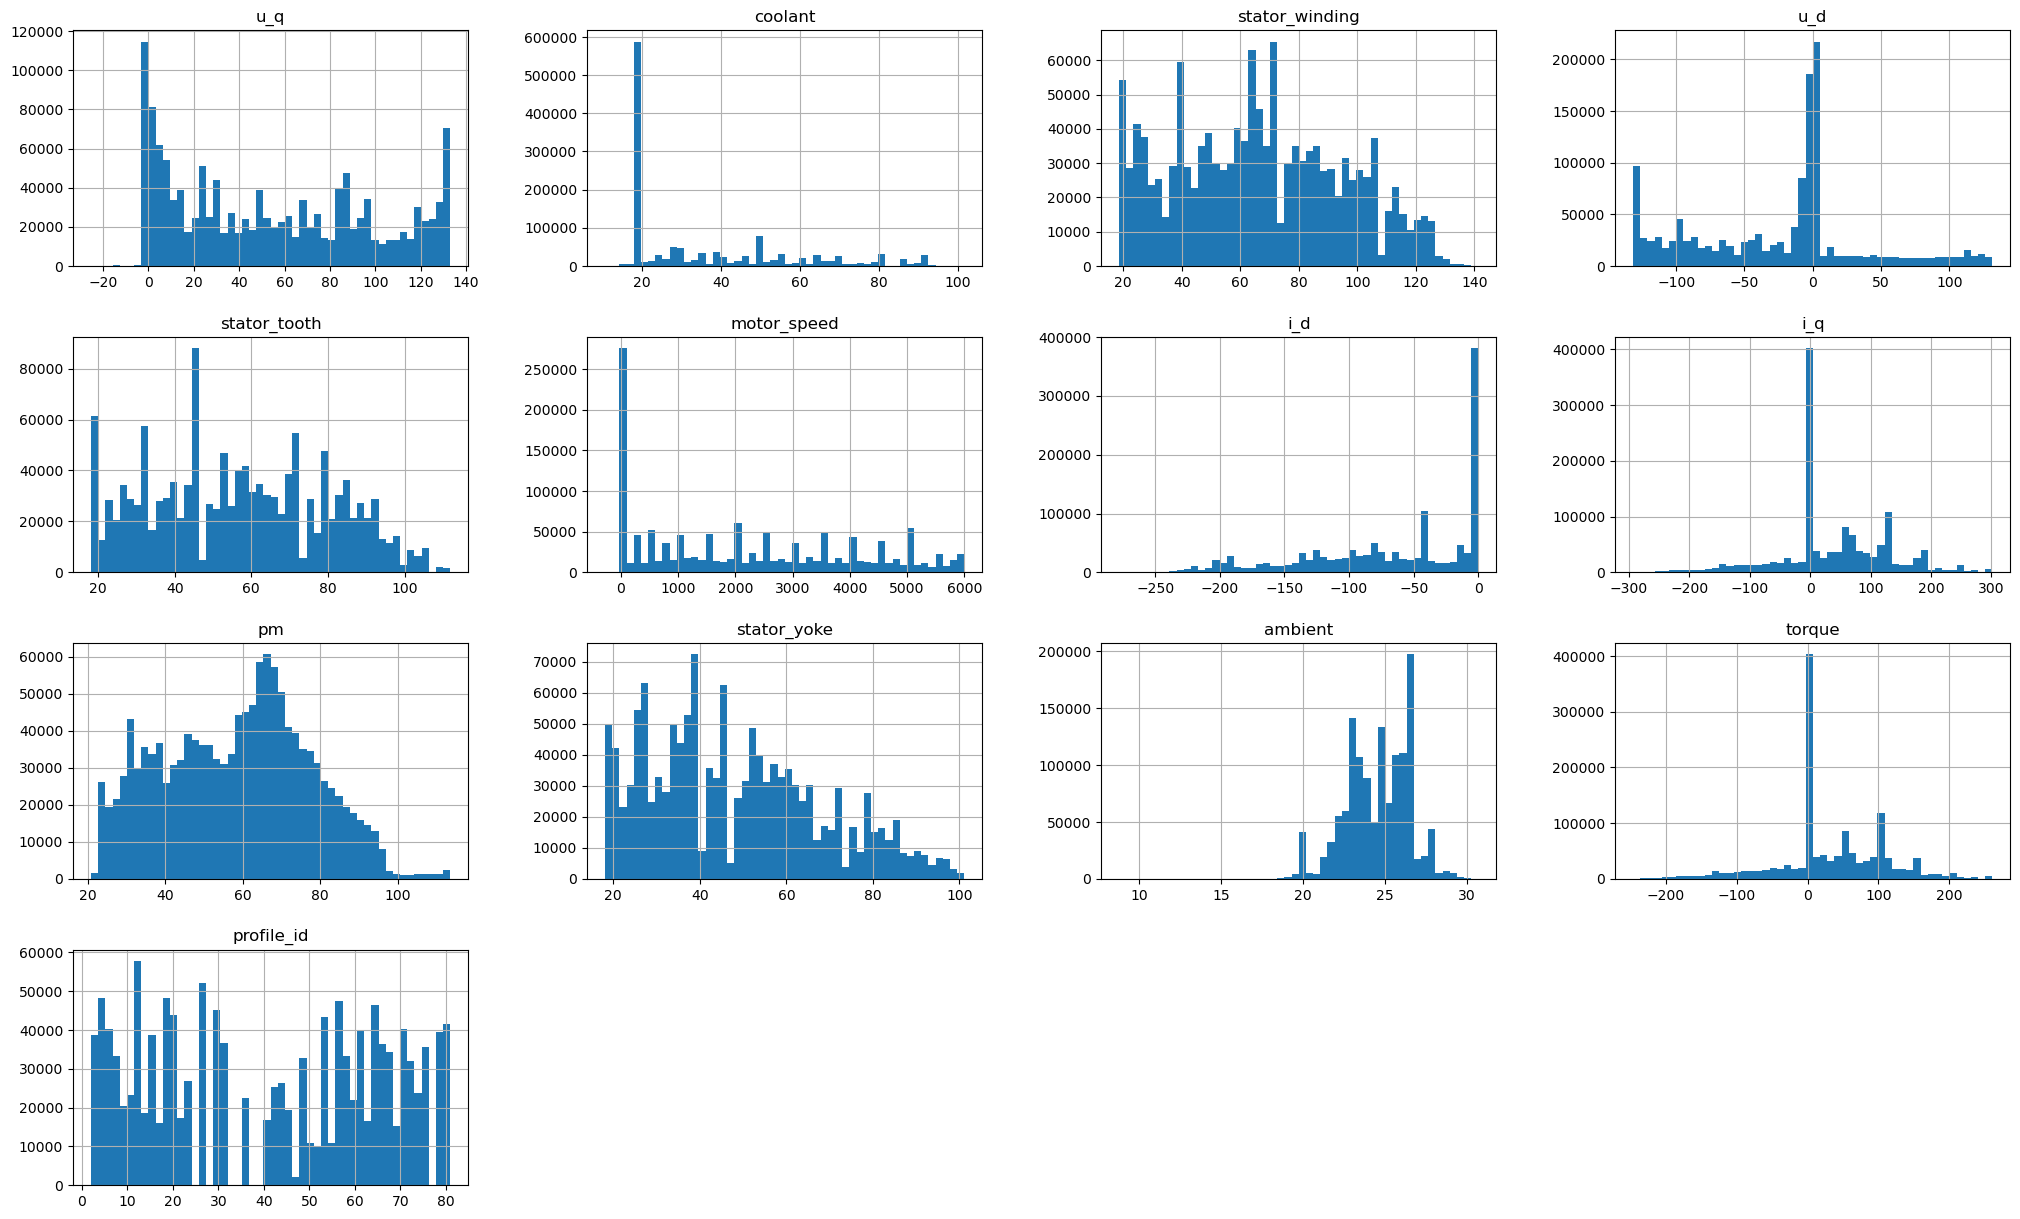

In [8]:
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(25,15))
plt.show()

### 2.2 Create a Test Set

In [11]:
from sklearn.model_selection import train_test_split # Import the libary to split the data

In [12]:
train_set, test_set = train_test_split(
    df,
    test_size = 0.2,
    random_state = 42
)

Now we have split the data:

- 80% = training set
- 20% = test set

In [13]:
print(len(train_set))
print(len(test_set))


1064652
266164


## 3. Explore the Data

### 3.1 Create a Copy of the Training Set

In [17]:
motor = train_set.copy()

The Copy of the Trining set is now named **motor**

### 3.2 Study the Attributes

We already got a first overview of the dataset. Now we repeat the analysis 
on the training set copy to ensure no information from the test set is used.

In [19]:
motor.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
1143828,71.573058,70.094127,116.319275,-108.308071,98.257279,5193.803338,-147.641244,57.593952,92.632259,83.741655,26.386337,53.853077,66
213758,4.843213,23.302538,124.166260,-130.518524,92.015007,3499.968750,-219.388290,113.765022,95.583832,64.013008,23.475470,110.886375,23
1286043,32.323607,27.261488,74.872633,-43.099145,61.188708,795.848780,-63.816320,169.103911,68.992171,49.245985,27.810407,131.605845,58
1076280,92.514180,35.819669,88.615951,92.919456,72.061041,5183.784198,-129.559204,-59.337778,75.580146,55.839309,26.471563,-55.032181,65
471043,63.622215,18.778725,39.515549,-63.737694,33.731060,1499.985718,-43.512409,132.617157,30.649586,28.016562,21.257879,103.281677,8


In [20]:
motor.info()

<class 'pandas.DataFrame'>
Index: 1064652 entries, 1143828 to 121958
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   u_q             1064652 non-null  float64
 1   coolant         1064652 non-null  float64
 2   stator_winding  1064652 non-null  float64
 3   u_d             1064652 non-null  float64
 4   stator_tooth    1064652 non-null  float64
 5   motor_speed     1064652 non-null  float64
 6   i_d             1064652 non-null  float64
 7   i_q             1064652 non-null  float64
 8   pm              1064652 non-null  float64
 9   stator_yoke     1064652 non-null  float64
 10  ambient         1064652 non-null  float64
 11  torque          1064652 non-null  float64
 12  profile_id      1064652 non-null  int64  
dtypes: float64(12), int64(1)
memory usage: 113.7 MB


In [21]:
motor.describe()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
count,1.064652e+06,1.064652e+06,1.064652e+06,1.064652e+06,1.064652e+06,1.064652e+06,1.064652e+06,1.064652e+06,1.064652e+06,1.064652e+06,1.064652e+06,1.064652e+06,1.064652e+06
mean,5.428801e+01,3.622851e+01,6.632312e+01,-2.513193e+01,5.686445e+01,2.202216e+03,-6.870672e+01,3.742281e+01,5.849213e+01,4.817875e+01,2.456456e+01,3.111441e+01,4.079454e+01
std,4.417574e+01,2.178789e+01,2.867312e+01,6.307835e+01,2.295311e+01,1.859937e+03,6.493142e+01,9.216390e+01,1.900022e+01,1.999380e+01,1.930202e+00,7.712161e+01,2.504813e+01
min,-2.529093e+01,1.062375e+01,1.858582e+01,-1.315304e+02,1.813398e+01,-2.755491e+02,-2.780036e+02,-2.934268e+02,2.085696e+01,1.807669e+01,8.783478e+00,-2.464511e+02,2.000000e+00
25%,1.207070e+01,1.869825e+01,4.278312e+01,-7.869056e+01,3.839993e+01,3.163581e+02,-1.154403e+02,1.095859e+00,4.313981e+01,3.195988e+01,2.318442e+01,-1.383246e-01,1.700000e+01
50%,4.893927e+01,2.689874e+01,6.508521e+01,-7.371790e+00,5.602978e+01,1.999977e+03,-5.099023e+01,1.577401e+01,6.023954e+01,4.561846e+01,2.479698e+01,1.085934e+01,4.300000e+01
75%,9.007503e+01,4.985740e+01,8.809381e+01,1.470345e+00,7.557480e+01,3.760522e+03,-2.979684e+00,1.005624e+02,7.199855e+01,6.145100e+01,2.621629e+01,9.137659e+01,6.500000e+01
max,1.330313e+02,1.015985e+02,1.413629e+02,1.314698e+02,1.119464e+02,6.000015e+03,2.668374e-02,3.017079e+02,1.136066e+02,1.011480e+02,3.069054e+01,2.609997e+02,8.100000e+01


Test if there are any missing values:

In [27]:
motor.isnull().sum() / len(motor) * 100

u_q               0.0
coolant           0.0
stator_winding    0.0
u_d               0.0
stator_tooth      0.0
motor_speed       0.0
i_d               0.0
i_q               0.0
pm                0.0
stator_yoke       0.0
ambient           0.0
torque            0.0
profile_id        0.0
dtype: float64

### 3.3 Identify the target attribute

The target attribute is `pm` (permanent magnet temperature in °C). 
This is the variable we want to predict with our model.

<Axes: >

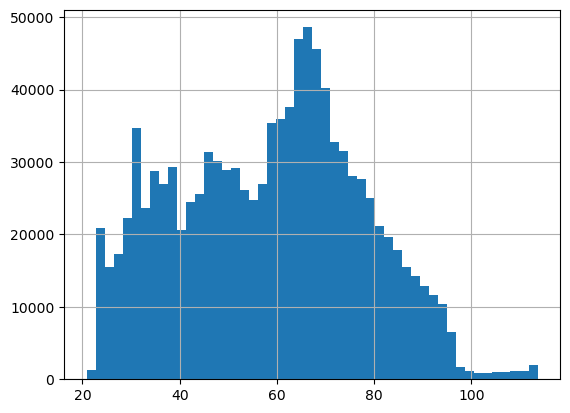

In [26]:
motor["pm"].hist(bins=50)

### 3.4 Visualize the Data

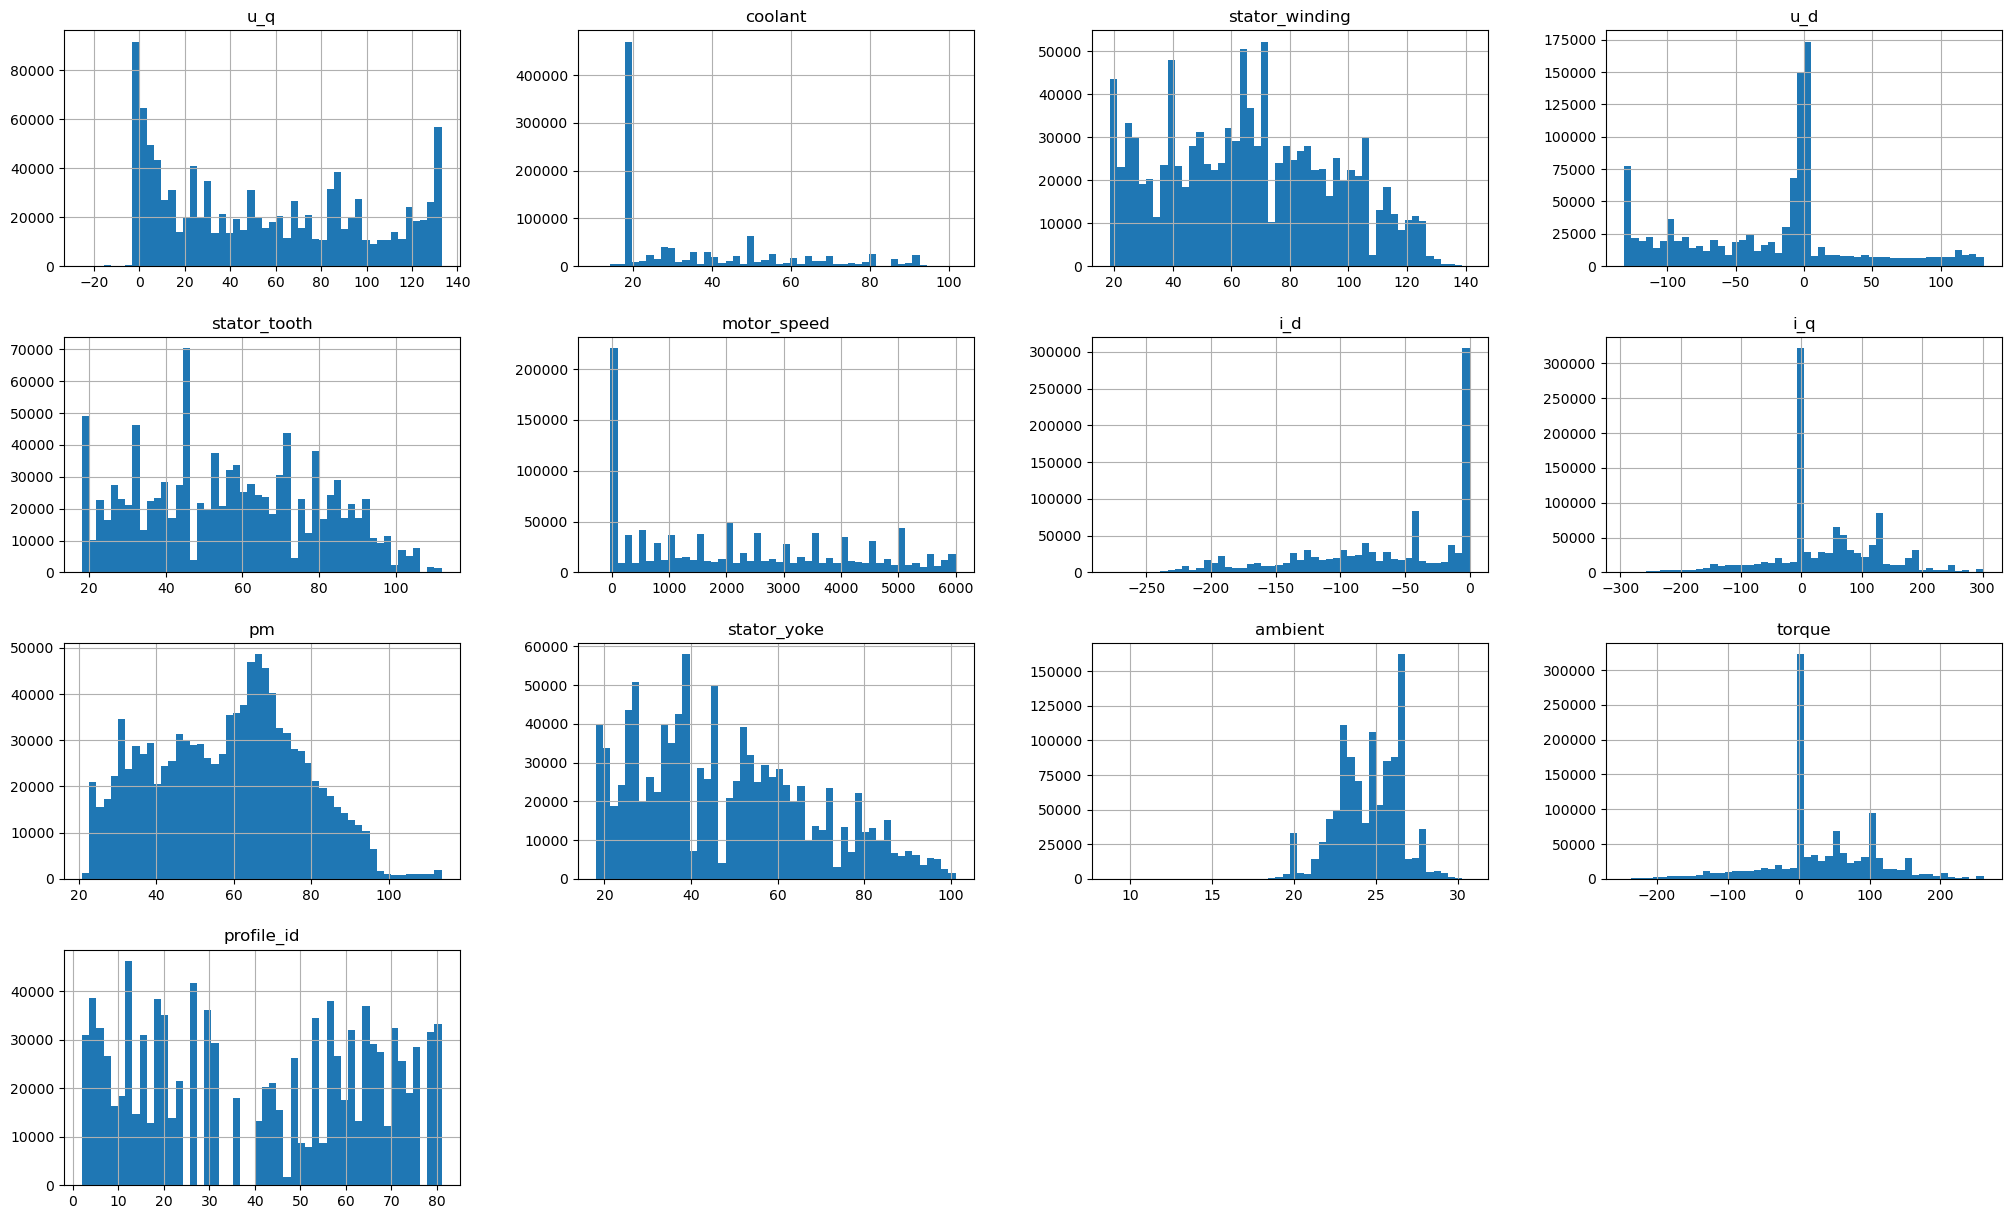

In [22]:
motor.hist(bins=50, figsize=(25,15))
plt.show()

### 3.5 Study correlations 

<Axes: >

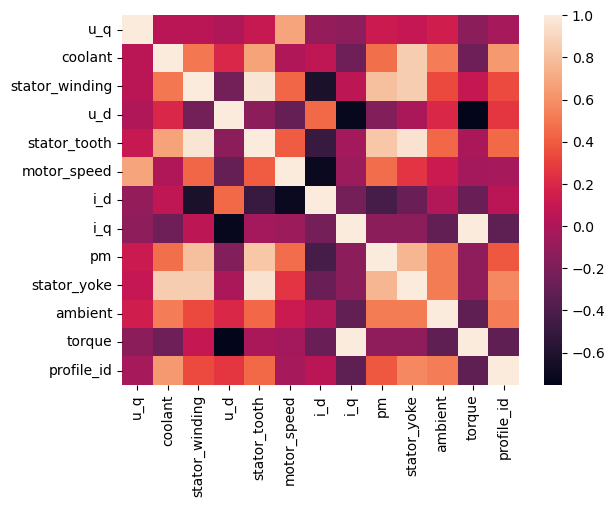

In [14]:
import seaborn as sns
# calculate correlations
#data.describe()
corr = train_set.corr()

# print heatmap
sns.heatmap(corr)

We've plot a heatmap of the trainingset, to get an idea of what correlations to expect

We can already see, whis features corralate with the taret value `pm`

**HIER DIE KORRELATIONEN NOCH GENAUER BESCHREIBEN**

We can see, that there are no missing values at all :)

### 3.6 Identify the promising transformations

## 4. Prepare the Data

# Meine erste Änderung